In [1]:
# import libraries and modules required
import tensorflow as tf
import keras
from tensorflow.keras import *
from tensorflow.keras.models import *
from tensorflow.keras.losses import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.utils import *
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Activation
import tensorflow.keras.backend as K

import glob, os, cv2
import numpy as np
from tqdm import tqdm

In [2]:
# 이미지가 들어 있는 폴더 경로
DATASET_PATH = r"C:\Users\user\Desktop\2.annotator\track_dataset"

# 이미지 파일 목록 불러오기 (확장자가 .jpg인 경우)
file_list = glob.glob(os.path.join(DATASET_PATH, "*.jpg"))

In [3]:
# Save the desired output (goal) with the input data
label = []
img = []

for file in tqdm(file_list):
    X = cv2.imread(file)

    try:
        # 파일 이름만 추출
        filename = os.path.basename(file)

        # 예: '123_145.jpg' → x=123, y=145
        x_val = float(filename.split('_')[0])
        y_val = float(filename.split('_')[1].split('.')[0])

        label.append([x_val, y_val])
        img.append(X[130:280, :])
    except Exception as e:
        print(f"Error processing {file}: {e}")
        pass

# numpy 배열로 변환
label = np.array(label)
img = np.array(img)

# 정규화: -1 ~ 1 범위로 조정
label = (label - 150) / 150

# 데이터 형태 출력
print("Label shape:", label.shape)
print("Image shape:", img.shape)

0it [00:00, ?it/s]

Label shape: (0,)
Image shape: (0,)


In [39]:
# define custom activation function
def mish(x):
  return x * K.tanh(K.softplus(x))

# define early stop configuration
def scheduler(epoch, learningrate):
  if epoch < 100:
    return learningrate
  else:
    return learningrate * tf.math.exp(-0.1)

get_custom_objects().update({'mish': Activation(mish)})

In [40]:
# define the architecture of a model
input1 = Input(shape=(150, 300, 3,))
conv1 = Conv2D(filters=16, kernel_size=(3, 3), strides=(2, 2), padding="same")(input1)
norm1 = BatchNormalization()(conv1)
act1 = Activation(mish)(norm1)
pool1 = MaxPooling2D(pool_size=(3, 3), strides=(2, 2))(act1)
conv2 = Conv2D(filters=32, kernel_size=(3, 3), strides=(2, 2), padding="same")(pool1)
norm2 = BatchNormalization()(conv2)
act2 = Activation(mish)(norm2)
conv3 = Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same")(act2)
norm3 = BatchNormalization()(conv3)
act3 = Activation(mish)(norm3)
add1 = Add()([act2, act3])
conv4 = Conv2D(filters=64, kernel_size=(3, 3), strides=(2, 2), padding="same")(add1)
norm4 = BatchNormalization()(conv4)
act4 = Activation(mish)(norm4)
conv5 = Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding="same")(act4)
norm5 = BatchNormalization()(conv5)
act5 = Activation(mish)(norm5)
add2 = Add()([act4, act5])
conv6 = Conv2D(filters=128, kernel_size=(3, 3), strides=(2, 2), padding="same")(add2)
norm6 = BatchNormalization()(conv6)
act6 = Activation(mish)(norm6)
conv7 = Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), padding="same")(act6)
norm7 = BatchNormalization()(conv7)
act7 = Activation(mish)(norm7)
add3 = Add()([act6, act7])
conv8 = Conv2D(filters=256, kernel_size=(3, 3), strides=(2, 2), padding="same")(add3)
norm8 = BatchNormalization()(conv8)
act8 = Activation(mish)(norm8)
conv9 = Conv2D(filters=512, kernel_size=(3, 3), strides=(2, 2), padding="same")(act8)
norm9 = BatchNormalization()(conv9)
act9 = Activation(mish)(norm9)
flat1 = Flatten()(act9)
dense1 = Dense(128)(flat1)
norm10 = BatchNormalization()(dense1)
act10 = Activation(mish)(norm10)
dense2 = Dense(64)(act10)
norm11 = BatchNormalization()(dense2)
act11 = Activation(mish)(norm11)
dense3 = Dense(64)(act11)
norm12 = BatchNormalization()(dense3)
act12 = Activation(mish)(norm12)
dense4 = Dense(1, activation="tanh")(act12)

model = Model(inputs=input1, outputs=dense4)

In [41]:
# set condition for training
es = EarlyStopping(monitor='val_loss', mode='min', patience=15, min_delta=1e-4)
mc = ModelCheckpoint(filepath='/content/drive/MyDrive/Track_M10.h5', monitor='val_loss', mode='min', save_best_only=True)
lr = LearningRateScheduler(scheduler)

opt = Adam()
model.compile(optimizer=opt, loss='MAE')
model.optimizer.lr.numpy()

0.001

In [42]:
# train
model.fit(x=img, y=label, epochs=1000, batch_size=32, validation_split=0.1, callbacks=[mc, es, lr])

Epoch 1/1000
83/83 [==============================] - 24s 275ms/step - loss: 0.1952 - val_loss: 0.8676 - lr: 0.0010
Epoch 2/1000
83/83 [==============================] - 13s 154ms/step - loss: 0.0655 - val_loss: 0.2831 - lr: 0.0010
Epoch 3/1000
83/83 [==============================] - 14s 166ms/step - loss: 0.0551 - val_loss: 0.2284 - lr: 0.0010
Epoch 4/1000
83/83 [==============================] - 11s 135ms/step - loss: 0.0527 - val_loss: 0.2320 - lr: 0.0010
Epoch 5/1000
83/83 [==============================] - 11s 135ms/step - loss: 0.0462 - val_loss: 0.2285 - lr: 0.0010
Epoch 6/1000
83/83 [==============================] - 11s 135ms/step - loss: 0.0462 - val_loss: 0.2355 - lr: 0.0010
Epoch 7/1000
83/83 [==============================] - 13s 162ms/step - loss: 0.0434 - val_loss: 0.2151 - lr: 0.0010
Epoch 8/1000
83/83 [==============================] - 11s 134ms/step - loss: 0.0430 - val_loss: 0.2219 - lr: 0.0010
Epoch 9/1000
83/83 [==============================] - 13s 153ms/step - l

In [ ]:
model_path = r"C:\Users\user15\Desktop\2.annotator\track_dataset\Track_Model_S_v1.h5"
model.save(model_path)

In [14]:
# Mish 활성화 함수 정의
def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))

# 모델 경로
model_path = r"C:\Users\user15\Desktop\2.annotator\track_dataset\Track_Model_S_v1.h5"

# 모델 로드 시 custom_objects에 mish 함수 추가
model = tf.keras.models.load_model(model_path, custom_objects={'mish': mish})

# 모델이 로드되었는지 확인
print("모델이 성공적으로 로드되었습니다.")


모델이 성공적으로 로드되었습니다.


In [15]:
data_path = r"C:\Users\user15\Desktop\2.annotator\track_dataset\3_3_2025-06-24_14_27_28.jpg"

# 이미지 로드
X = cv2.imread(data_path)
if X is None:
    raise FileNotFoundError(f"Image not found at: {data_path}")

# Crop 및 예측
crop_img = X[130:280, :]
prediction = model(np.array([crop_img]).astype(np.float32)).numpy()[0]

print("Prediction:", prediction)

Prediction: [0.0269788  0.03068009]


Prediction: 0.077890866


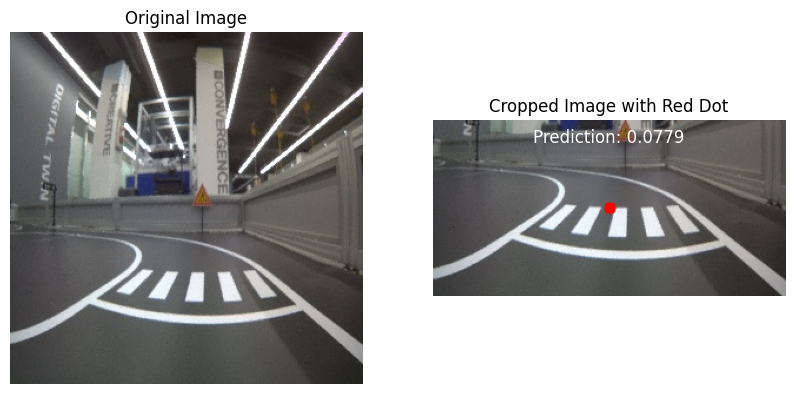

In [22]:
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 모델 경로
model_path = r"C:\Users\user15\Desktop\2.annotator\track_dataset\Track_Model_S_v1.h5"

# 모델 로드 (mish 활성화 함수가 필요할 경우)
def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))

model = tf.keras.models.load_model(model_path, custom_objects={'mish': mish})

# 이미지 경로
data_path = r"C:\Users\user15\Desktop\2.annotator\track_dataset\272_272_2025-06-24_14_31_58.jpg"

# 이미지 로드
X = cv2.imread(data_path)
if X is None:
    raise FileNotFoundError(f"Image not found at: {data_path}")

# Crop 이미지 (예: (130:280, :) 부분)
crop_img = X[130:280, :]

# 예측
prediction = model(np.array([crop_img]).astype(np.float32)).numpy()

# 예측값이 다차원 배열로 반환된 경우, 첫 번째 값만 추출
prediction_value = prediction[0] if prediction.ndim == 1 else prediction[0][0]

print("Prediction:", prediction_value)

# 원본 이미지와 크롭된 이미지를 시각적으로 표시
plt.figure(figsize=(10, 5))

# 원본 이미지
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(X, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# 크롭된 이미지
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
plt.title('Cropped Image')
plt.axis('off')

# 예측값을 기반으로 중앙값 계산
center_x = crop_img.shape[1] // 2  # 이미지 가로 중앙
center_y = crop_img.shape[0] // 2  # 이미지 세로 중앙

# 붉은 점으로 중앙값 표시
cv2.circle(crop_img, (center_x, center_y), 5, (0, 0, 255), -1)  # (0, 0, 255)는 빨간색

# 붉은 점을 추가한 이미지를 다시 출력
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB))
plt.title('Cropped Image with Red Dot')
plt.axis('off')

# 예측값을 중앙에 텍스트로 추가 (원하는 경우)
plt.text(0.5, 0.9, f'Prediction: {prediction_value:.4f}', color='white', fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)

plt.show()
